<a href="https://colab.research.google.com/github/Minetriforce/DL_project_traffic_signs/blob/main/project_traffic_signs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Partie 1 — Recherche, compréhension et préparation des données**

## **Description du dataset**


**GTSRB — German Traffic Sign Recognition Benchmark**

| Élément | Valeur |
|---|---|
| Source officielle | Institut für Neuroinformatik (INI), Ruhr-Universität Bochum : https://benchmark.ini.rub.de/ |
| Copie utilisée | Kaggle : https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign |
| Auteurs / référence | J. Stallkamp, M. Schlipsing, J. Salmen, C. Igel, *Man vs. computer: Benchmarking machine learning algorithms for traffic sign recognition*, Neural Networks, 2012 |
| Origine | Photos réelles de panneaux allemands, extraites de séquences vidéo prises sur route |
| Nombre de classe | 43 |
| Taille | 39 209 images d'entraînement + 12 630 images de test (≈ 51 800 au total) |
| Format | Images couleur RGB, fichiers `.png` (copie Kaggle), avec des CSV d'annotations (taille, zone du panneau, classe) |
| Dimensions | Variables : d'environ 15×15 à 250×250 pixels |
| Licence | Creative Commons Attribution 4.0 International (CC-BY-4.0)


**Pourquoi ce choix ?** Dataset de référence, bien documenté, assez grand pour entraîner un CNN, avec de vraies difficultés
(luminosité, flou, petite taille, classes proches comme les limitations de vitesse) qui nourriront les parties 5 et 6.

In [1]:
import kagglehub
import os
import matplotlib.pyplot as plt

#kagglehub.login()
DATA_PATH = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(DATA_PATH)
print(os.listdir(DATA_PATH))


100%|██████████| 612M/612M [00:07<00:00, 85.0MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1
['Meta', 'Test.csv', 'Meta.csv', 'test', 'train', 'Train.csv', 'meta', 'Test', 'Train']


In [2]:
DATA_PATH_TRAIN = os.path.join(DATA_PATH, 'Train')
DATA_PATH_TEST = os.path.join(DATA_PATH, 'Test')
DATA_PATH_META = os.path.join(DATA_PATH, 'Meta')

print(DATA_PATH_TRAIN)
print(DATA_PATH_TEST)
print(DATA_PATH_META)
NUM_CLASSES = 43
IMG_SIZE = 32 # Redimensionnement standard

CLASSES = {
 0:"Limitation 20 km/h", 1:"Limitation 30 km/h", 2:"Limitation 50 km/h", 3:"Limitation 60 km/h",
 4:"Limitation 70 km/h", 5:"Limitation 80 km/h", 6:"Fin de limitation 80 km/h", 7:"Limitation 100 km/h",
 8:"Limitation 120 km/h", 9:"Interdiction de dépasser", 10:"Interdiction de dépasser (camions)",
 11:"Intersection avec priorité", 12:"Route prioritaire", 13:"Cédez le passage", 14:"STOP",
 15:"Circulation interdite", 16:"Interdit aux camions", 17:"Sens interdit", 18:"Danger général",
 19:"Virage dangereux à gauche", 20:"Virage dangereux à droite", 21:"Succession de virages",
 22:"Cassis ou dos-d'âne", 23:"Chaussée glissante", 24:"Chaussée rétrécie (droite)", 25:"Travaux",
 26:"Feux tricolores", 27:"Passage piétons", 28:"Enfants", 29:"Cyclistes", 30:"Verglas / neige",
 31:"Animaux sauvages", 32:"Fin de toutes interdictions", 33:"Obligation : à droite",
 34:"Obligation : à gauche", 35:"Obligation : tout droit", 36:"Obligation : tout droit ou droite",
 37:"Obligation : tout droit ou gauche", 38:"Contourner l'obstacle par la droite", 39:"Contourner l'obstacle par la gauche",
 40:"Rond-point", 41:"Fin interdiction de dépasser", 42:"Fin interdiction de dépasser (camions)"}

print("Nombre de classes : ", NUM_CLASSES)

/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/Train
/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/Test
/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/Meta
Nombre de classes :  43


0    | Limitation 20 km/h                       | 210
1    | Limitation 30 km/h                       | 2220
2    | Limitation 50 km/h                       | 2250
3    | Limitation 60 km/h                       | 1410
4    | Limitation 70 km/h                       | 1980
5    | Limitation 80 km/h                       | 1860
6    | Fin de limitation 80 km/h                | 420
7    | Limitation 100 km/h                      | 1440
8    | Limitation 120 km/h                      | 1410
9    | Interdiction de dépasser                 | 1470
10   | Interdiction de dépasser (camions)       | 2010
11   | Intersection avec priorité               | 1320
12   | Route prioritaire                        | 2100
13   | Cédez le passage                         | 2160
14   | STOP                                     | 780
15   | Circulation interdite                    | 630
16   | Interdit aux camions                     | 420
17   | Sens interdit                            | 1110
18   | Danger g

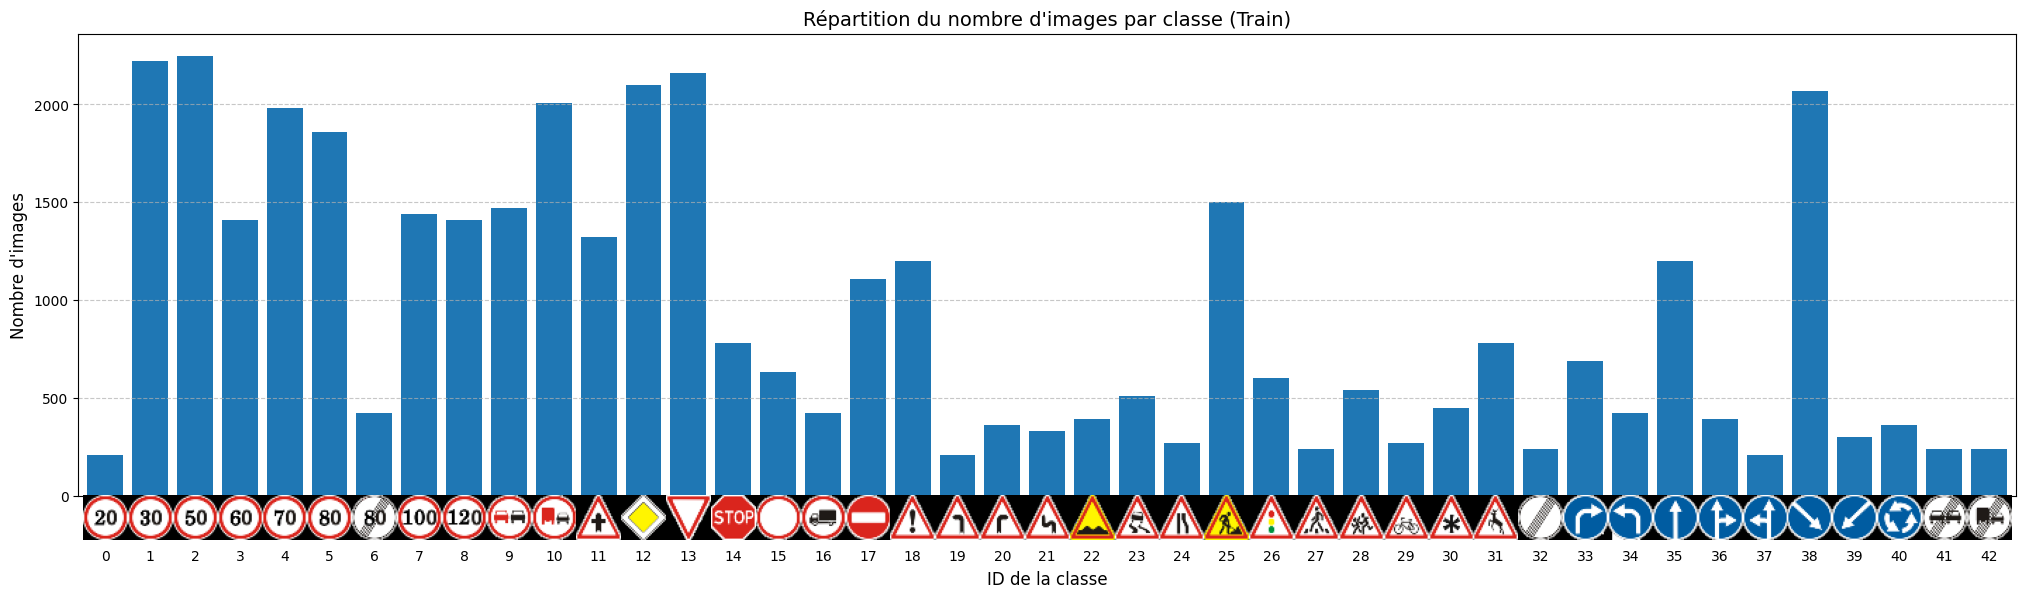

In [3]:
import cv2
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

image_counts = {}
reference_images = {}

for class_id in range(NUM_CLASSES):
    folder_path = os.path.join(DATA_PATH_TRAIN, str(class_id))
    icon_path = os.path.join(DATA_PATH_META, f"{class_id}.png")

    if os.path.isdir(folder_path):
        num_images = len([f for f in os.listdir(folder_path) if f.endswith('.png')])
        image_counts[class_id] = num_images

        class_name = CLASSES[class_id]
        print(f"{class_id:<4} | {class_name:<40} | {num_images}")

        # Chargement de l'icône de référence depuis le dossier Meta
        if os.path.exists(icon_path):
            img = cv2.imread(icon_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_icon = cv2.resize(img, (32, 32))
            reference_images[class_id] = img_icon
        else:
          print("Problème avec le chemin de fichiers vers les icônes")
    else:
        print("Problème avec le chemin de fichiers de la base de test")

print('\n')


# Histogramme
plt.figure(figsize=(25, 6))
ax = plt.gca() # Récupère l'axe actuel pour manipuler les icônes
ax.bar(image_counts.keys(), image_counts.values())
ax.set_title("Répartition du nombre d'images par classe (Train)", fontsize=14)
ax.set_xlabel("ID de la classe", fontsize=12, labelpad=5) # labelpad éloigne le titre de l'axe pour faire de la place
ax.set_ylabel("Nombre d'images", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
# Configuration de l'axe X pour afficher les numéros
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(range(NUM_CLASSES))
# décale les numéros vers le bas pour glisser l'image au-dessus
ax.tick_params(axis='x', pad=35)
ax.set_xlim(-0.6, NUM_CLASSES - 0.4) # réduit les marges latérales

# Placement des icônes du dossier Meta
for class_id in range(NUM_CLASSES):
    if class_id in reference_images:
        imagebox = OffsetImage(reference_images[class_id], zoom=1)
        # xybox=(0, -16) positionne l'image juste sous la ligne zéro, au-dessus du chiffre
        ab = AnnotationBbox(imagebox, (class_id, 0),
                            xybox=(0, -16),
                            xycoords='data',
                            boxcoords="offset points",
                            frameon=False)
        ax.add_artist(ab)

plt.show()

On peut observer un grand déséquilibre entre les classes, par exemple il y a 10 fois plus de limitations de vitesse à 50km qu'il n'y en a pour 20km

## **Préparation des données**

Dans un premier temps, nous allons parcourir l'ensemble des images contenus dans le fichier Train afin d'en tirer une liste d'images et une liste de lablel.
Ce parcours va également nous permettre de normaliser les pixels et redimensionner chaque images.
Pour le redimensionnemnet, nous avons choisis une taille de 32x32 pixels car c'était le meilleur compris, assez proche de la dimension médiane, qui n'allait pas trop déformer les images avec des dimensions extrêmes.

Chargement des images depuis /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/Train...


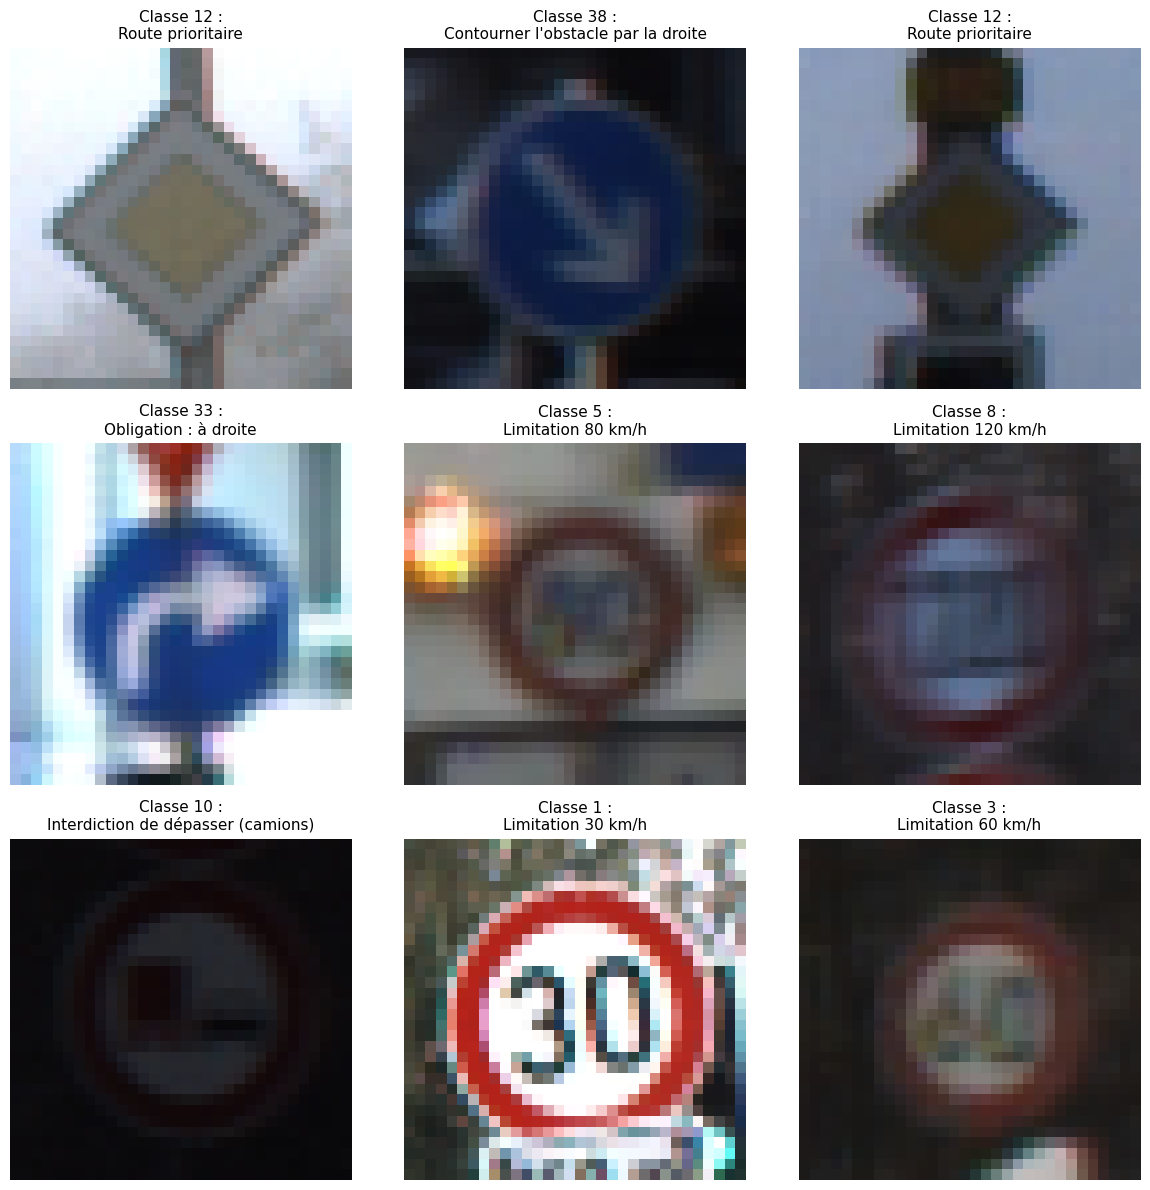

In [4]:
import numpy as np

images = []
labels = []

print(f"Chargement des images depuis {DATA_PATH_TRAIN}...")
for class_id in range(NUM_CLASSES):
    folder_path = os.path.join(DATA_PATH_TRAIN, str(class_id))

    if os.path.isdir(folder_path):
        for img_name in os.listdir(folder_path):
            if img_name.endswith('.png'):
                img_path = os.path.join(folder_path, img_name)
                img = cv2.imread(img_path)

                if img is not None:
                    # Conversion BGR (OpenCV) vers RGB (Standard)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    # Redimensionnement
                    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                    images.append(img_resized)
                    labels.append(class_id)

images = np.array(images)
labels = np.array(labels)

# Normalisation des pixels par division par 255
images = images.astype('float32') / 255.0

# Affichage d'une grille de 9 images aléatoires
plt.figure(figsize=(12, 12))

# On génère 9 indices aléatoires pour piocher dans le dataset
for i in range(9):
    plt.subplot(3, 3, i + 1)

    # Choix d'une image au hasard dans la liste globale 'images'
    idx = np.random.randint(0, len(images))

    # Affichage de l'image
    plt.imshow(images[idx])

    # Récupération de l'ID et du nom de la classe
    class_id = labels[idx]
    class_name = CLASSES[class_id]

    # Titre avec le numéro et le texte
    plt.title(f"Classe {class_id} :\n{class_name}", fontsize=11)
    plt.axis('off') # On masque les axes pour faire plus propre

plt.tight_layout()
plt.show()

Le morceau de code qui suis correspond à la séparation des données d'entrainement en un ensemble d'entrainement et un ensemble de validation grâce à la fonciont train_test_split de sklearn.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Génération des ensembles de train et de validation
X_train, X_val, y_train, y_val = train_test_split(
    images,
    labels,
    test_size=0.20,
    random_state=42
)

# One hot encoding
y_train = to_categorical(y_train, NUM_CLASSES)
y_val = to_categorical(y_val, NUM_CLASSES)

print(f"Entraînement : {X_train.shape} | Labels : {y_train.shape}")
print(f"Validation   : {X_val.shape} | Labels : {y_val.shape}")

# Chargement des données de test à partir de Test.csv et du dossier Test
csv_path = os.path.join(DATA_PATH, 'Test.csv')
test_df = pd.read_csv(csv_path)

X_test = []
y_test = []

print(f"Chargement des images de test depuis {DATA_PATH_TEST}...")
for index, row in test_df.iterrows():
    # Le fichier CSV contient le chemin relatif 'Path' (ex: Test/00000.png)
    # On extrait le nom de l'image et on reconstruit le chemin complet
    img_name = os.path.basename(row['Path'])
    img_path = os.path.join(DATA_PATH_TEST, img_name)

    img = cv2.imread(img_path)
    if img is not None:
        # Conversion BGR vers RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Redimensionnement
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X_test.append(img_resized)
        y_test.append(row['ClassId'])

X_test = np.array(X_test)
y_test = np.array(y_test)

# Normalisation des pixels
X_test = X_test.astype('float32') / 255.0

# One hot encoding test
y_test = to_categorical(y_test, NUM_CLASSES)

print(f"Test         : {X_test.shape} | Labels : {y_test.shape}")

Entraînement : (31367, 32, 32, 3) | Labels : (31367, 43)
Validation   : (7842, 32, 32, 3) | Labels : (7842, 43)
Chargement des images de test depuis /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/Test...
Test         : (12630, 32, 32, 3) | Labels : (12630, 43)


In [6]:
"""La fonction plot_history permet un affichage détaillé des courbes de pertes et
de précision des modèles utilisés dans les parties suivantes."""

def plot_history(h, title=""):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    ax[0].plot(h["loss"], label="train")
    ax[0].plot(h["val_loss"], label="validation")
    ax[0].set_title(f"Loss {title}")
    ax[0].set_xlabel("époque")
    ax[0].set_xticks(range(len(h["loss"])))
    ax[0].set_xticklabels(range(1, len(h["loss"]) + 1))
    ax[0].grid(True, linestyle=':', alpha=0.7)
    ax[0].legend()

    ax[1].plot(h["accuracy"], label="train")
    ax[1].plot(h["val_accuracy"], label="validation")
    ax[1].set_title(f"Accuracy {title}")
    ax[1].set_xlabel("époque")
    ax[1].set_xticks(range(len(h["loss"])))
    ax[1].set_xticklabels(range(1, len(h["loss"]) + 1))
    ax[1].grid(True, linestyle=':', alpha=0.7)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

# **Partie 2 — Construction d’un modèle de référence**

## **Création et entrainement du modèle de référence**
Nous avons choisis l'architecture suivante pour notre modèle de référence : <br>
$X \to \text{Flatten} \to z_1 = X \cdot W_1 + b_1 \to a_1 = \text{ReLU}(z_1) \to z_2 = a_1 \cdot W_2 + b_2 \to \hat{y} = \text{Softmax}(z_2)$<br>
De plus nous avons choisis une seule couche de neuronnes de 128 neuronnes.

In [7]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Input

baseline_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 398,891 (1.52 MB)

 Trainable params: 398,891 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Dans la suite de cette partie, nous avons compiler le modèla à l'aide de l'optimiseur ADAM et la fonction de perte categorical_crossentropy.<br>
Enfin, nous entrainons le modèle avec nos données d'entrainemnet et de validation précédemment établis.

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5036 - loss: 2.0466 - val_accuracy: 0.7054 - val_loss: 1.2448
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7669 - loss: 0.9712 - val_accuracy: 0.8073 - val_loss: 0.7979
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8361 - loss: 0.6759 - val_accuracy: 0.8619 - val_loss: 0.6127
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8687 - loss: 0.5414 - val_accuracy: 0.8599 - val_loss: 0.5730
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8860 - loss: 0.4611 - val_accuracy: 0.8470 - val_loss: 0.5767
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8982 - loss: 0.4130 - val_accuracy: 0.8855 - val_loss: 0.4674
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9042 - loss: 0.3821 - val_accuracy: 0.8985 - val_loss: 0.4105
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9164 - loss: 0.3394 - val_accuracy: 0

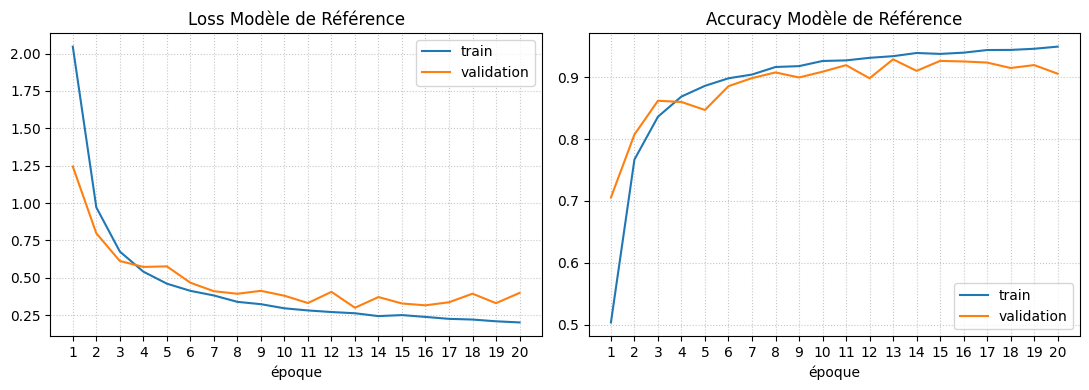

In [8]:
# Compilation du modèle
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entraînement du modèle
history_baseline = baseline_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

h_baseline = history_baseline.history

# Affichage des courbes de perte et de précision
plot_history(h_baseline, title="Modèle de Référence")

**Observation des courbes**<br>
On peut voir que les deux courbes présentent une variation rapide puis s'applatissent ce qui démontre un bon taux d'apprentissage. De plus la courbe de validation suis la courbe d'apprentissage sur les deux diagrammes ce qui nous permet de valider le modèle.

## **Explications théoriques du modèle de référence**

Voici un récapitulatif des notions à connaitre et leurs applications à notre modèle de référence :

| Concept | Définition / Principe | Application au modèle de référence |
| :--- | :--- | :--- |
| **1. Entrée du réseau** | Transformation d'un tenseur 3D `(H, L, C)` en un vecteur 1D plat et linéaire. | La couche `Flatten` convertit l'image de dimension $(32, 32, 3)$ en un unique vecteur de $3072$ valeurs d'intensités de pixels.
| **2. Poids ($W$) & Biais ($b$)** | Les poids mesurent l'influence d'un neurone sur le suivant. <br>Le biais ajuste le seuil de déclenchement du neurone ($z = X \cdot W + b$). | La première couche Dense possède $3072 \times 128 = 393\,216$ poids et $128$ biais entraînables.
| **3. Propagation avant** | Processus séquentiel de calculs mathématiques allant de la couche d'entrée vers la couche de sortie pour générer une prédiction. | $X \to \text{Flatten} \to z_1 = X \cdot W_1 + b_1 \to a_1 = \text{ReLU}(z_1) \to z_2 = a_1 \cdot W_2 + b_2 \to \hat{y} = \text{Softmax}(z_2)$.
| **4. Fonctions d'activation** | Introduir de la non-linéarité pour permettre au réseau d'apprendre des relations complexes et non-linéaires. | ReLU sur la couche cachée remplace les valeurs négatives par $0$. Softmax sur la couche de sortie convertit les scores en probabilités.
| **5. Fonction de perte** | Mesure l'écart ou l'erreur entre la prédiction du modèle ($\hat{y}$) et la vrai valeur ($y$). | On utilise la Categorical Crossentropy car nos labels ont été convertis sous forme vectorielle one-hot de dimension $43$.
| **6. Rétropropagation** | Algorithme calculant le gradient de la perte par rapport aux paramètres (poids et biais) en remontant le réseau de la fin vers le début. | Utilise la dérivation en chaîne pour évaluer l'impact de chaque poids sur l'erreur finale.
| **7. Descente de gradient** | Algorithme d'optimisation qui met à jour les paramètres dans le sens inverse du gradient pour minimiser l'erreur. | L'optimiseur Adam ajuste dynamiquement le taux d'apprentissage pour mettre à jour les poids : $W \leftarrow W - \eta \frac{\partial L}{\partial W}$.
| **8. Classification multiclasse** | La couche finale fournit un score de confiance normalisé sous forme de distribution probabiliste pour chaque classe. | La sortie contient $43$ neurones activés par Softmax. La classe finale retenue est l'indice ayant la probabilité la plus élevée.

In [9]:
import pickle

# Sauvegarde du modèle de référence
baseline_model.save("baseline_model.keras")

# Sauvegarde l'historique d'entrainement du modèle de référence
with open("h_baseline.pkl", "wb") as f:
    pickle.dump(h_baseline, f)

In [ ]:
!wget https://raw.githubusercontent.com/Minetriforce/DL_project_traffic_signs/main/saves/history/h_baseline.pkl
!wget https://raw.githubusercontent.com/Minetriforce/DL_project_traffic_signs/main/saves/models/baseline_model.keras

In [ ]:
import pickle
from tensorflow.keras.models import load_model

# Récupération de l'historique d'entrainement et du modèle de référence
with open('h_baseline.pkl', 'rb') as f:
    h_baseline = pickle.load(f)

baseline_model = load_model('baseline_model.keras')

# **Partie 3 — Construction d'un CNN avec Keras**

## **Choix de l'architecture**

L'architecture choisie est un réseau de neurones convolutif (CNN) adapté à la classification d'images. L'image d'entrée possède une taille de **32 × 32 pixels avec 3 canaux de couleur (RGB)**. Le réseau est composé de trois blocs convolution + ReLU + MaxPooling, suivis d'une couche Flatten, d'une couche Dense de 128 neurones et d'une couche de sortie de 43 neurones.

Image 32×32×3  
 --> Conv2D(32, 3×3, same) + ReLU → MaxPooling 2×2  
 --> Conv2D(64, 3×3, same) + ReLU → MaxPooling 2×2  
 --> Conv2D(128, 3×3, same) + ReLU → MaxPooling 2×2  
 --> Flatten → Dense(128) + ReLU → Dense(43) + Softmax  

In [10]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
    )

tensorflow.random.set_seed(42)

In [11]:
CHANNEL = 3

cnn_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, CHANNEL)),

    Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,067 (1.38 MB)

 Trainable params: 361,067 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

## **Justification de l'architecture**

| Élément| Principe| Rôle dans notre architecture|
| ------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1. Les filtres**                          | Un filtre est une petite matrice de poids qui parcourt l'image afin de détecter certaines caractéristiques.  <br> Chaque filtre apprend automatiquement à reconnaître des motifs comme des contours, des formes ou des couleurs.                                                                                                                  | La première convolution utilise **32 filtres**, la deuxième **64** et la troisième **128**. <br> Le nombre de filtres augmente afin de permettre au réseau d'apprendre progressivement des caractéristiques plus complexes.                   |
| **2. La convolution sur une image couleur** | Une image RGB possède **3 canaux** : rouge, vert et bleu. <br>Un filtre de taille 3×3 travaille donc sur les trois canaux simultanément. <br>Dans la première couche, un filtre possède ainsi une dimension **3×3×3**. <br>Il effectue des multiplications entre ses poids et les valeurs des pixels, puis additionne les résultats et ajoute un biais. | La convolution permet d'extraire automatiquement les caractéristiques importantes de l'image. <br>Par exemple Les 32 filtres de la première couche produisent 32 représentations différentes de l'image.                                                 |
| **3. Les feature maps**                     | Une feature map est le résultat obtenu après l'application d'un filtre de convolution sur l'image. <br>Elle indique notamment les zones où la caractéristique recherchée est présente.<br>Plus on avance dans le réseau, plus les feature maps représentent des caractéristiques complexes.                                                                                                                                                          | Chaque filtre produit une feature map. Avec 32 filtres, la première convolution produit **32 feature maps**. <br>Les couches suivantes en produisent respectivement **64 puis 128**.                                                         |
| **4. La taille du kernel**                  | Le kernel correspond à la zone de l'image observée par le filtre à chaque position. <br>Ici, sa taille est de **3×3**.                                                                                                                                                                                                                          | Le kernel 3×3 permet d'observer des caractéristiques locales de l'image tout en conservant un nombre raisonnable de paramètres.<br> Plusieurs convolutions successives permettent ensuite de construire des caractéristiques plus complexes. |
| **5. Le stride**                            | Le stride correspond au nombre de pixels dont le filtre se déplace à chaque étape.                                                                                                                                                                                                                                                          | Nous utilisons un **stride de 1** pour les convolutions. <br>Le filtre se déplace donc pixel par pixel. <br>Associé au padding « same », cela permet de conserver la largeur et la hauteur des feature maps après chaque convolution.            |
| **6. Le padding**                           | Le padding consiste à ajouter une bordure de pixels autour de l'image avant la convolution. <br>Avec **padding = "same"**, la taille spatiale est conservée.                                                                                                                                                                                    | Une image de **32×32** reste donc **32×32** après la première convolution. <br>Cela permet notamment de ne pas perdre trop rapidement les informations situées sur les bords de l'image.                                                     |
| **7. ReLU**                                 | ReLU signifie *Rectified Linear Unit* et correspond à la fonction $\text{ReLU(}x\text{)} = \max(0,x)$. <br>Les valeurs négatives sont remplacées par 0.                                                                                                                                                                                                      | ReLU introduit de la non-linéarité dans le réseau. <br>Elle permet ainsi au CNN d'apprendre des relations et des caractéristiques complexes. <br>Elle est appliquée après chaque convolution et après la couche Dense de 128 neurones.           |
| **8. Le pooling**                           | Le MaxPooling sélectionne la valeur maximale dans chaque zone de **2×2**. <br>Il réduit ainsi la largeur et la hauteur des données tout en conservant les caractéristiques les plus importantes.                                                                                                                                                | Les trois opérations MaxPooling permettent de réduire progressivement la résolution : **32×32 → 16×16 → 8×8 → 4×4**. <br>Cela réduit également le coût des calculs et le risque de surapprentissage.                                         |
| **9. Flatten**                              | Flatten transforme un tenseur multidimensionnel en un vecteur à une seule dimension.                                                                                                                                                                                                                                                        | Après les trois blocs convolutionnels, nous obtenons **4×4×128**. <br> Flatten transforme cette représentation en un vecteur de **2048 valeurs**, car **4×4×128 = 2048**.                                                                     |
| **10. Les couches Dense**                   | Une couche Dense est une couche entièrement connectée : <br>chaque neurone reçoit les informations provenant de tous les neurones de la couche précédente.                                                                                                                                                                                      | La couche Dense contient **128 neurones** et utilise ReLU. <br>Elle permet de combiner les caractéristiques extraites par les couches convolutives afin de déterminer la classe de l'image.                                                  |
| **11. La couche de sortie**                 | La dernière couche contient un neurone par classe. <br>La fonction **Softmax** transforme les sorties en probabilités dont la somme est égale à 1.                                                                                                                                                                                              | Notre problème comporte **43 classes**, donc la couche de sortie contient **43 neurones**. <br>Le neurone ayant la probabilité la plus élevée correspond à la classe prédite par le réseau.                                                  |



## **Evolution des dimensions et des paramètres**

| Couche (Type) | Dimension de sortie | Nombre de paramètres | Détail du calcul mathématique |
| --- | --- | --- | --- |
| **Conv 1** | `(None, 32, 32, 32)`<br> | 896 | $((3 \times 3 \text{ pixels} \times 3 \text{ canaux}) + 1 \text{ biais}) \times 32 \text{ filtres}$|
| **MaxPooling 1** | `(None, 16, 16, 32)`| 0| Extraction de la valeur maximale, aucun poids à apprendre. |
| **Conv 2** | `(None, 16, 16, 64)`<br> | 18 496| $((3 \times 3 \text{ pixels} \times 32 \text{ canaux en entrée}) + 1 \text{ biais}) \times 64 \text{ filtres}$ |
| **MaxPooling 2** | `(None, 8, 8, 64)`<br> | 0| Extraction de la valeur maximale, aucun poids à apprendre. |
| **Conv 3** | `(None, 8, 8, 128)`<br> | 73 856| $((3 \times 3 \text{ pixels} \times 64 \text{ canaux en entrée}) + 1 \text{ biais}) \times 128 \text{ filtres}$ |
| **MaxPooling 3** | `(None, 4, 4, 128)`<br> | 0| Extraction de la valeur maximale, aucun poids à apprendre. |
| **Flatten** | `(None, 2048)`<br> | 0| Aplatissement du volume : $4 \times 4 \times 128 = 2048$. |
| **Dense 1**| `(None, 128)`<br> | 262 272| $(2048 \text{ entrées} + 1 \text{ biais}) \times 128 \text{ neurones}$ |
| **Dense 2** | `(None, 43)`<br> | 5 547| $(128 \text{ entrées} + 1 \text{ biais}) \times 43 \text{ neurones en sortie}$ |
| **Total** |  | **361 067**<br> | Somme totale de tous les paramètres entraînables.|

Cette évolution montre que le réseau **réduit progressivement la résolution spatiale de l'image tout en augmentant le nombre de caractéristiques extraites**. On passe ainsi de **32 × 32 × 3** à **4 × 4 × 128**, puis à un vecteur de **2048 valeurs** utilisé par les couches Dense pour effectuer la classification finale en **43 classes**.

# **Partie 4 — Entraînement du réseau**

Lors de l'entrainement, étant donnée que nous avons en sortie plusieurs classes et que chaque classe est un nombre en One hot encoding, nous utiliserons `categorical_crossentropy` comme fonction de perte.
Adam (Adaptive Moment Estimation) est utilisée comme optimiseur pour sa praticité de ne pas avoir à régler soi-même le learning rate.  
On propose ici de parcourir 20 époques avec des lots de 32.

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6383 - loss: 1.2724 - val_accuracy: 0.8988 - val_loss: 0.3385
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9502 - loss: 0.1720 - val_accuracy: 0.9697 - val_loss: 0.1061
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9804 - loss: 0.0714 - val_accuracy: 0.9767 - val_loss: 0.0872
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9885 - loss: 0.0413 - val_accuracy: 0.9881 - val_loss: 0.0499
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9905 - loss: 0.0336 - val_accuracy: 0.9792 - val_loss: 0.0758
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9921 - loss: 0.0262 - val_accuracy: 0.9850 - val_loss: 0.0583
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9922 - loss: 0.0255 - val_accuracy: 0.9880 - val_loss: 0.0516
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9961 - loss: 0.0137 - val_accuracy: 

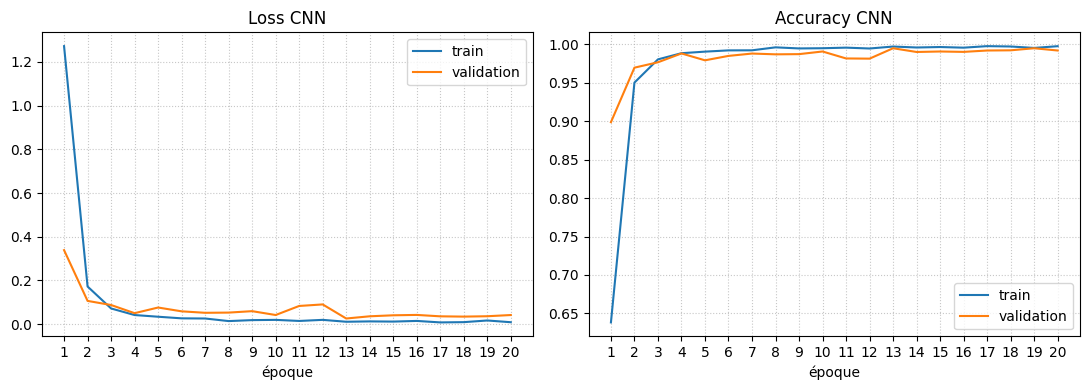

In [12]:
# Compilation du modèle
cnn_model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Entraînement du modèle
history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

h_cnn = history_cnn.history

# Affichage des courbes d'apprentissage
plot_history(h_cnn, "CNN")

- La perte d'entraînement chute de manière continue. Elle descend très bas très vite, et atteint des valeurs infimes en fin de cycle.

- La perte de validation suit globalement la même dynamique. Elle descend très vite lors des premières époques, connaît de légères secousses, avant de se stabiliser.


- L'accuracy d'entraînement montre que le modèle apprend extrêmement vite au départ.

- L'accuracy de validation est assez élevée dès le départ et s'améliore.  


Le modèle présente d'excellentes performances, une convergence rapide et une grande stabilité en fin d'entraînement.  
Il n'y a aucun surapprentissage significatif sur ces 20 époques.  

Le surapprentissage se manifeste généralement lorsque la loss d'entraînement continue de baisser tandis que la loss de validation se met à remonter de façon prolongée, signe que le modèle commence à apprendre par cœur et perd sa capacité de généralisation.  
Ici, malgré quelques petites oscillations de la val_loss en milieu de parcours, la courbe globale de validation finit par redescendre à son point le plus bas à l'époque 20.

Le modèle semble assez bien généraliser sur les données qu'il ne connaît pas.

In [13]:
import pickle

# Sauvegarde du modèle classique CNN
cnn_model.save("cnn_model.keras")

# Sauvegarde l'historique d'entrainement du CNN
with open("h_cnn.pkl", "wb") as f:
    pickle.dump(h_cnn, f)

In [ ]:
!wget https://raw.githubusercontent.com/Minetriforce/DL_project_traffic_signs/main/saves/history/h_cnn.pkl
!wget https://raw.githubusercontent.com/Minetriforce/DL_project_traffic_signs/main/saves/models/cnn_model.keras

In [ ]:
import pickle
from tensorflow.keras.models import load_model

# Récupération de l'historique d'entrainement et du modèle classique CNN
with open('h_cnn.pkl', 'rb') as f:
    h_cnn = pickle.load(f)

cnn_model = load_model('cnn_model.keras')

# **Partie 5 — Évaluation et analyse des erreurs**

Nous allons maintenant comparer les matrices de confusion des deux modèles et analyser nos résultats.

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


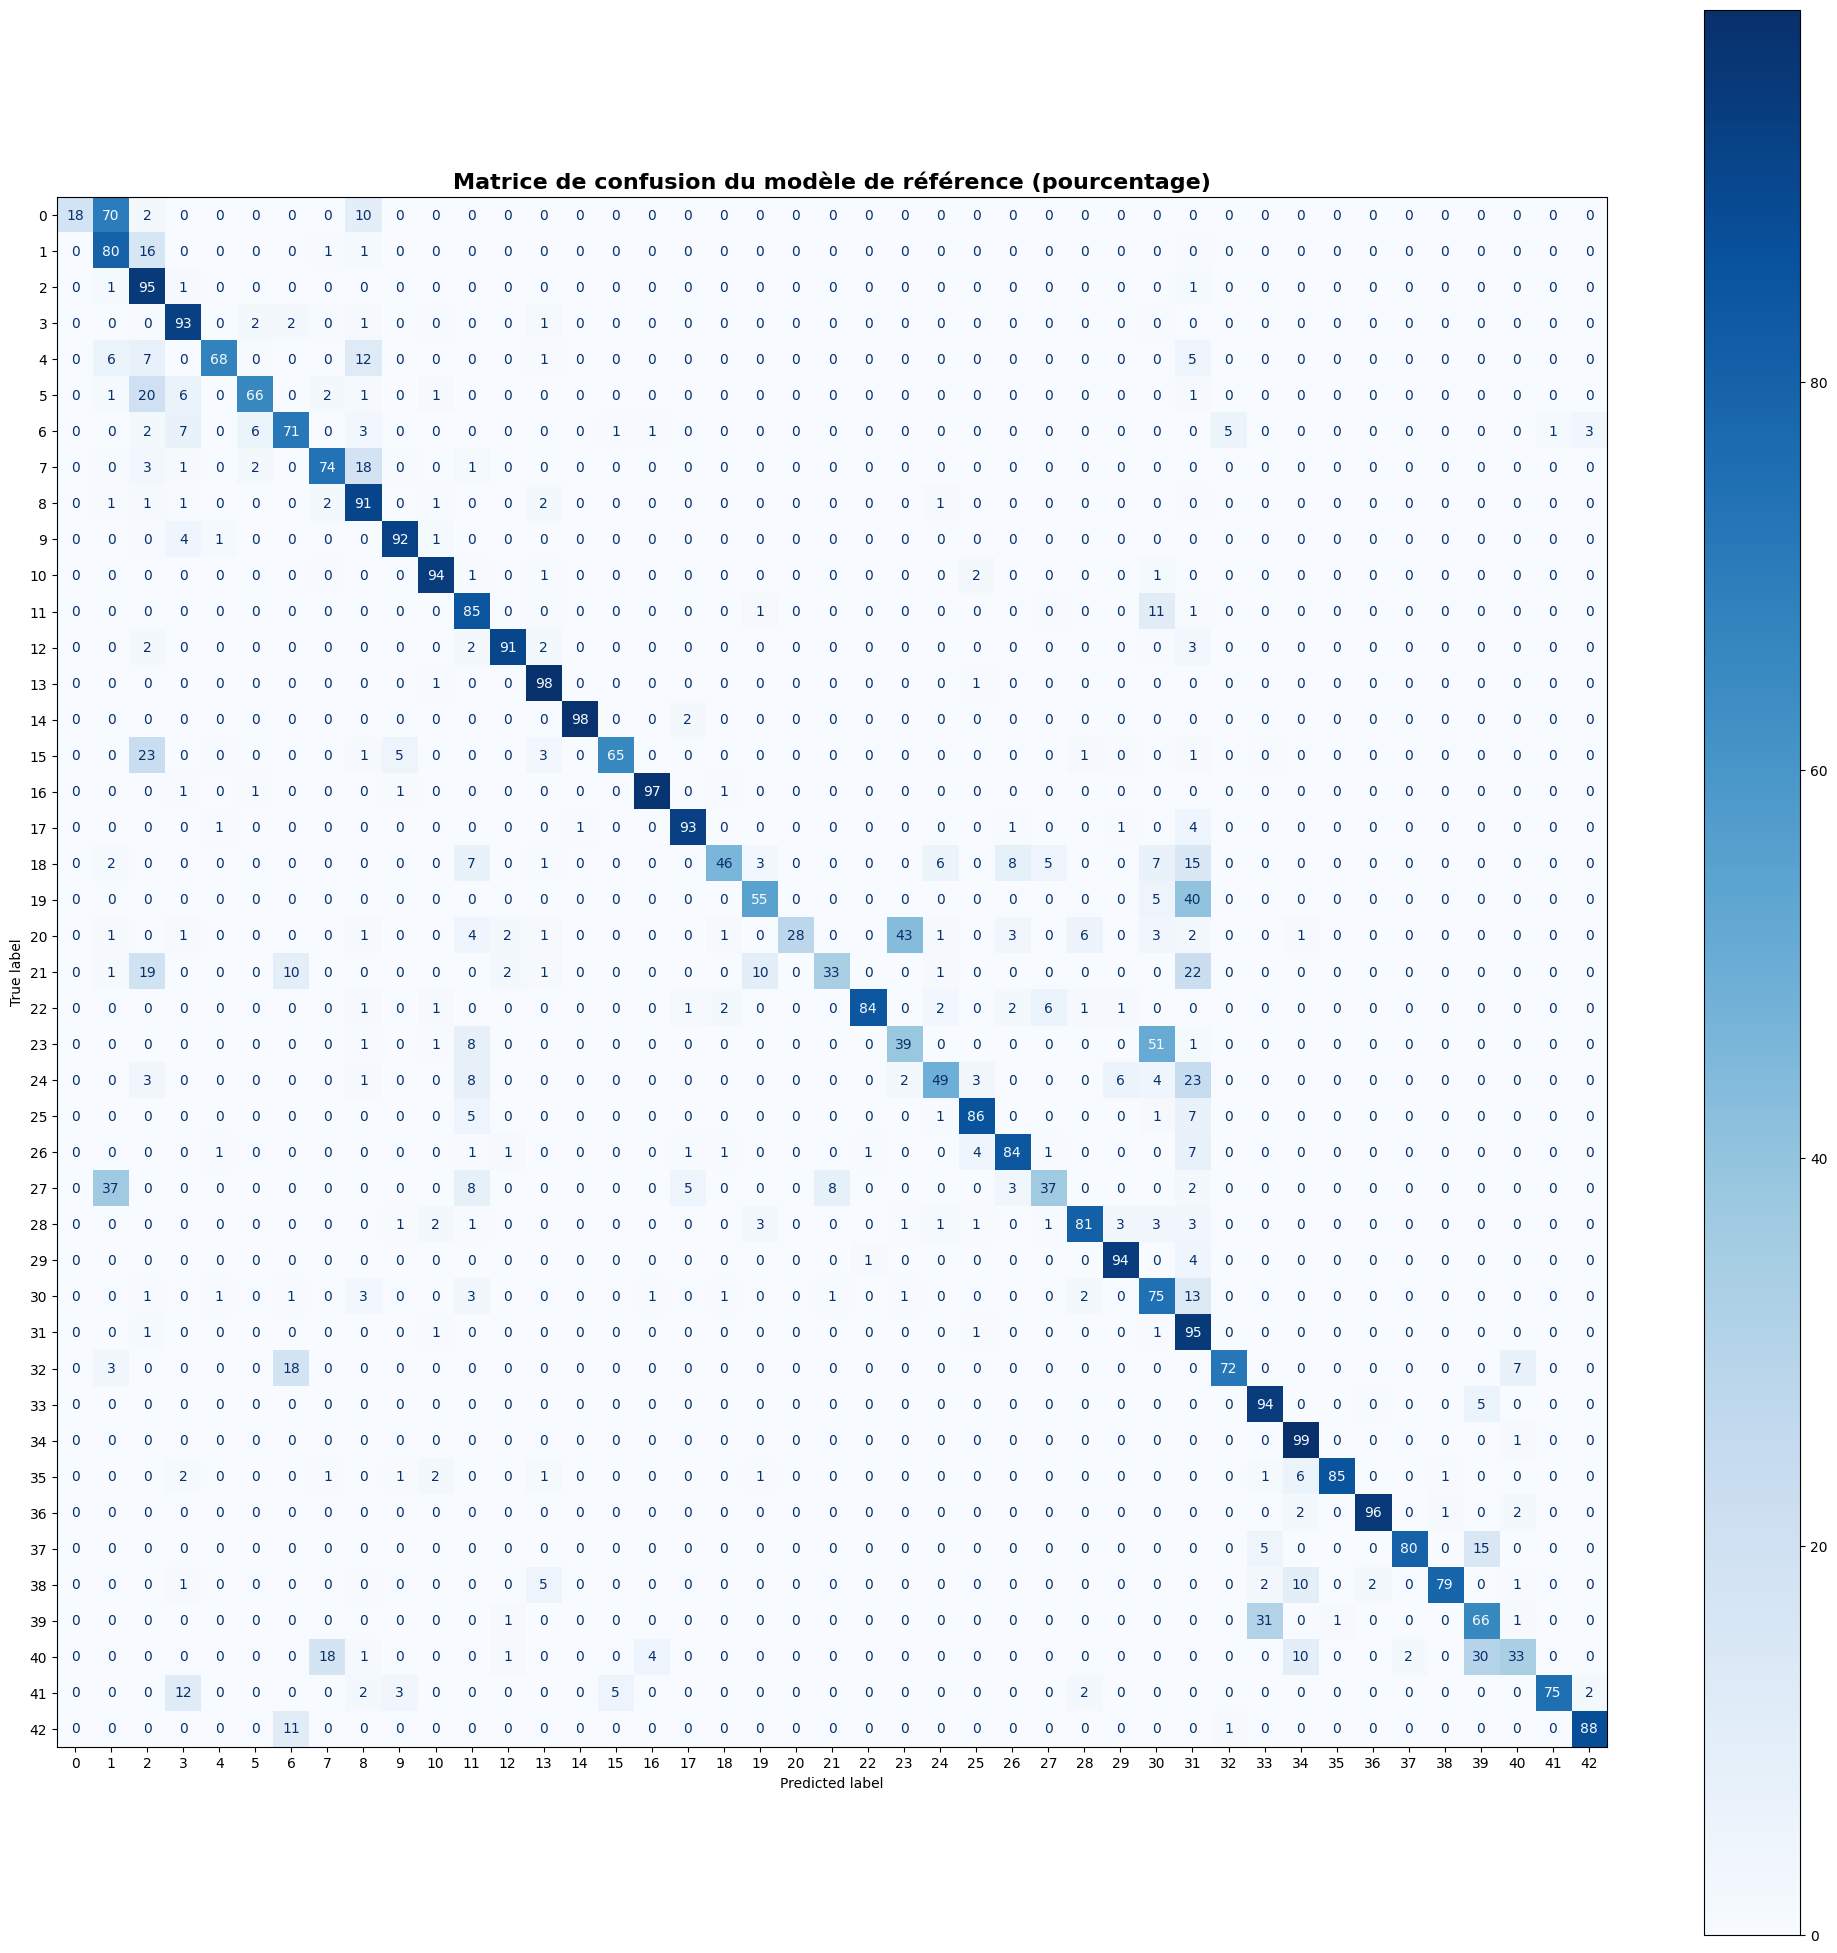

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Génération des prédictions
y_pred_ref = np.argmax(baseline_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Calcul de la matrice de confusion
cm_ref = confusion_matrix(y_true, y_pred_ref, normalize='true') * 100

# Création d'une figure assez grande pour 43 classes
fig, ax = plt.subplots(figsize=(25, 25))

# Affichage
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ref)
disp.plot(cmap=plt.cm.Blues, values_format='.0f', ax=ax)

plt.title("Matrice de confusion du modèle de référence (pourcentage)", fontsize=16, fontweight='bold')
plt.show()

In [15]:
test_loss_ref, test_acc_ref = baseline_model.evaluate(X_test, y_test)

print(f"Loss: {test_loss_ref:.2f}")
print(f"Accuracy: {test_acc_ref:.2f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8163 - loss: 1.1089
Loss: 1.11
Accuracy: 0.82


In [16]:
from sklearn.metrics import classification_report

# On génère une liste des noms de classes pour que le tableau soit lisible
noms_classes = [CLASSES[i] for i in range(NUM_CLASSES)]

# Génération et affichage du rapport
rapport_ref = classification_report(y_true, y_pred_ref, target_names=noms_classes)
print(rapport_ref)

                                        precision    recall  f1-score   support

                    Limitation 20 km/h       0.92      0.18      0.31        60
                    Limitation 30 km/h       0.81      0.80      0.80       720
                    Limitation 50 km/h       0.64      0.95      0.77       750
                    Limitation 60 km/h       0.79      0.93      0.85       450
                    Limitation 70 km/h       0.96      0.68      0.80       660
                    Limitation 80 km/h       0.92      0.66      0.77       630
             Fin de limitation 80 km/h       0.74      0.71      0.73       150
                   Limitation 100 km/h       0.86      0.74      0.80       450
                   Limitation 120 km/h       0.66      0.91      0.77       450
              Interdiction de dépasser       0.95      0.92      0.94       480
    Interdiction de dépasser (camions)       0.94      0.94      0.94       660
            Intersection avec priorité 

##**Réseau de neuronnes**

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


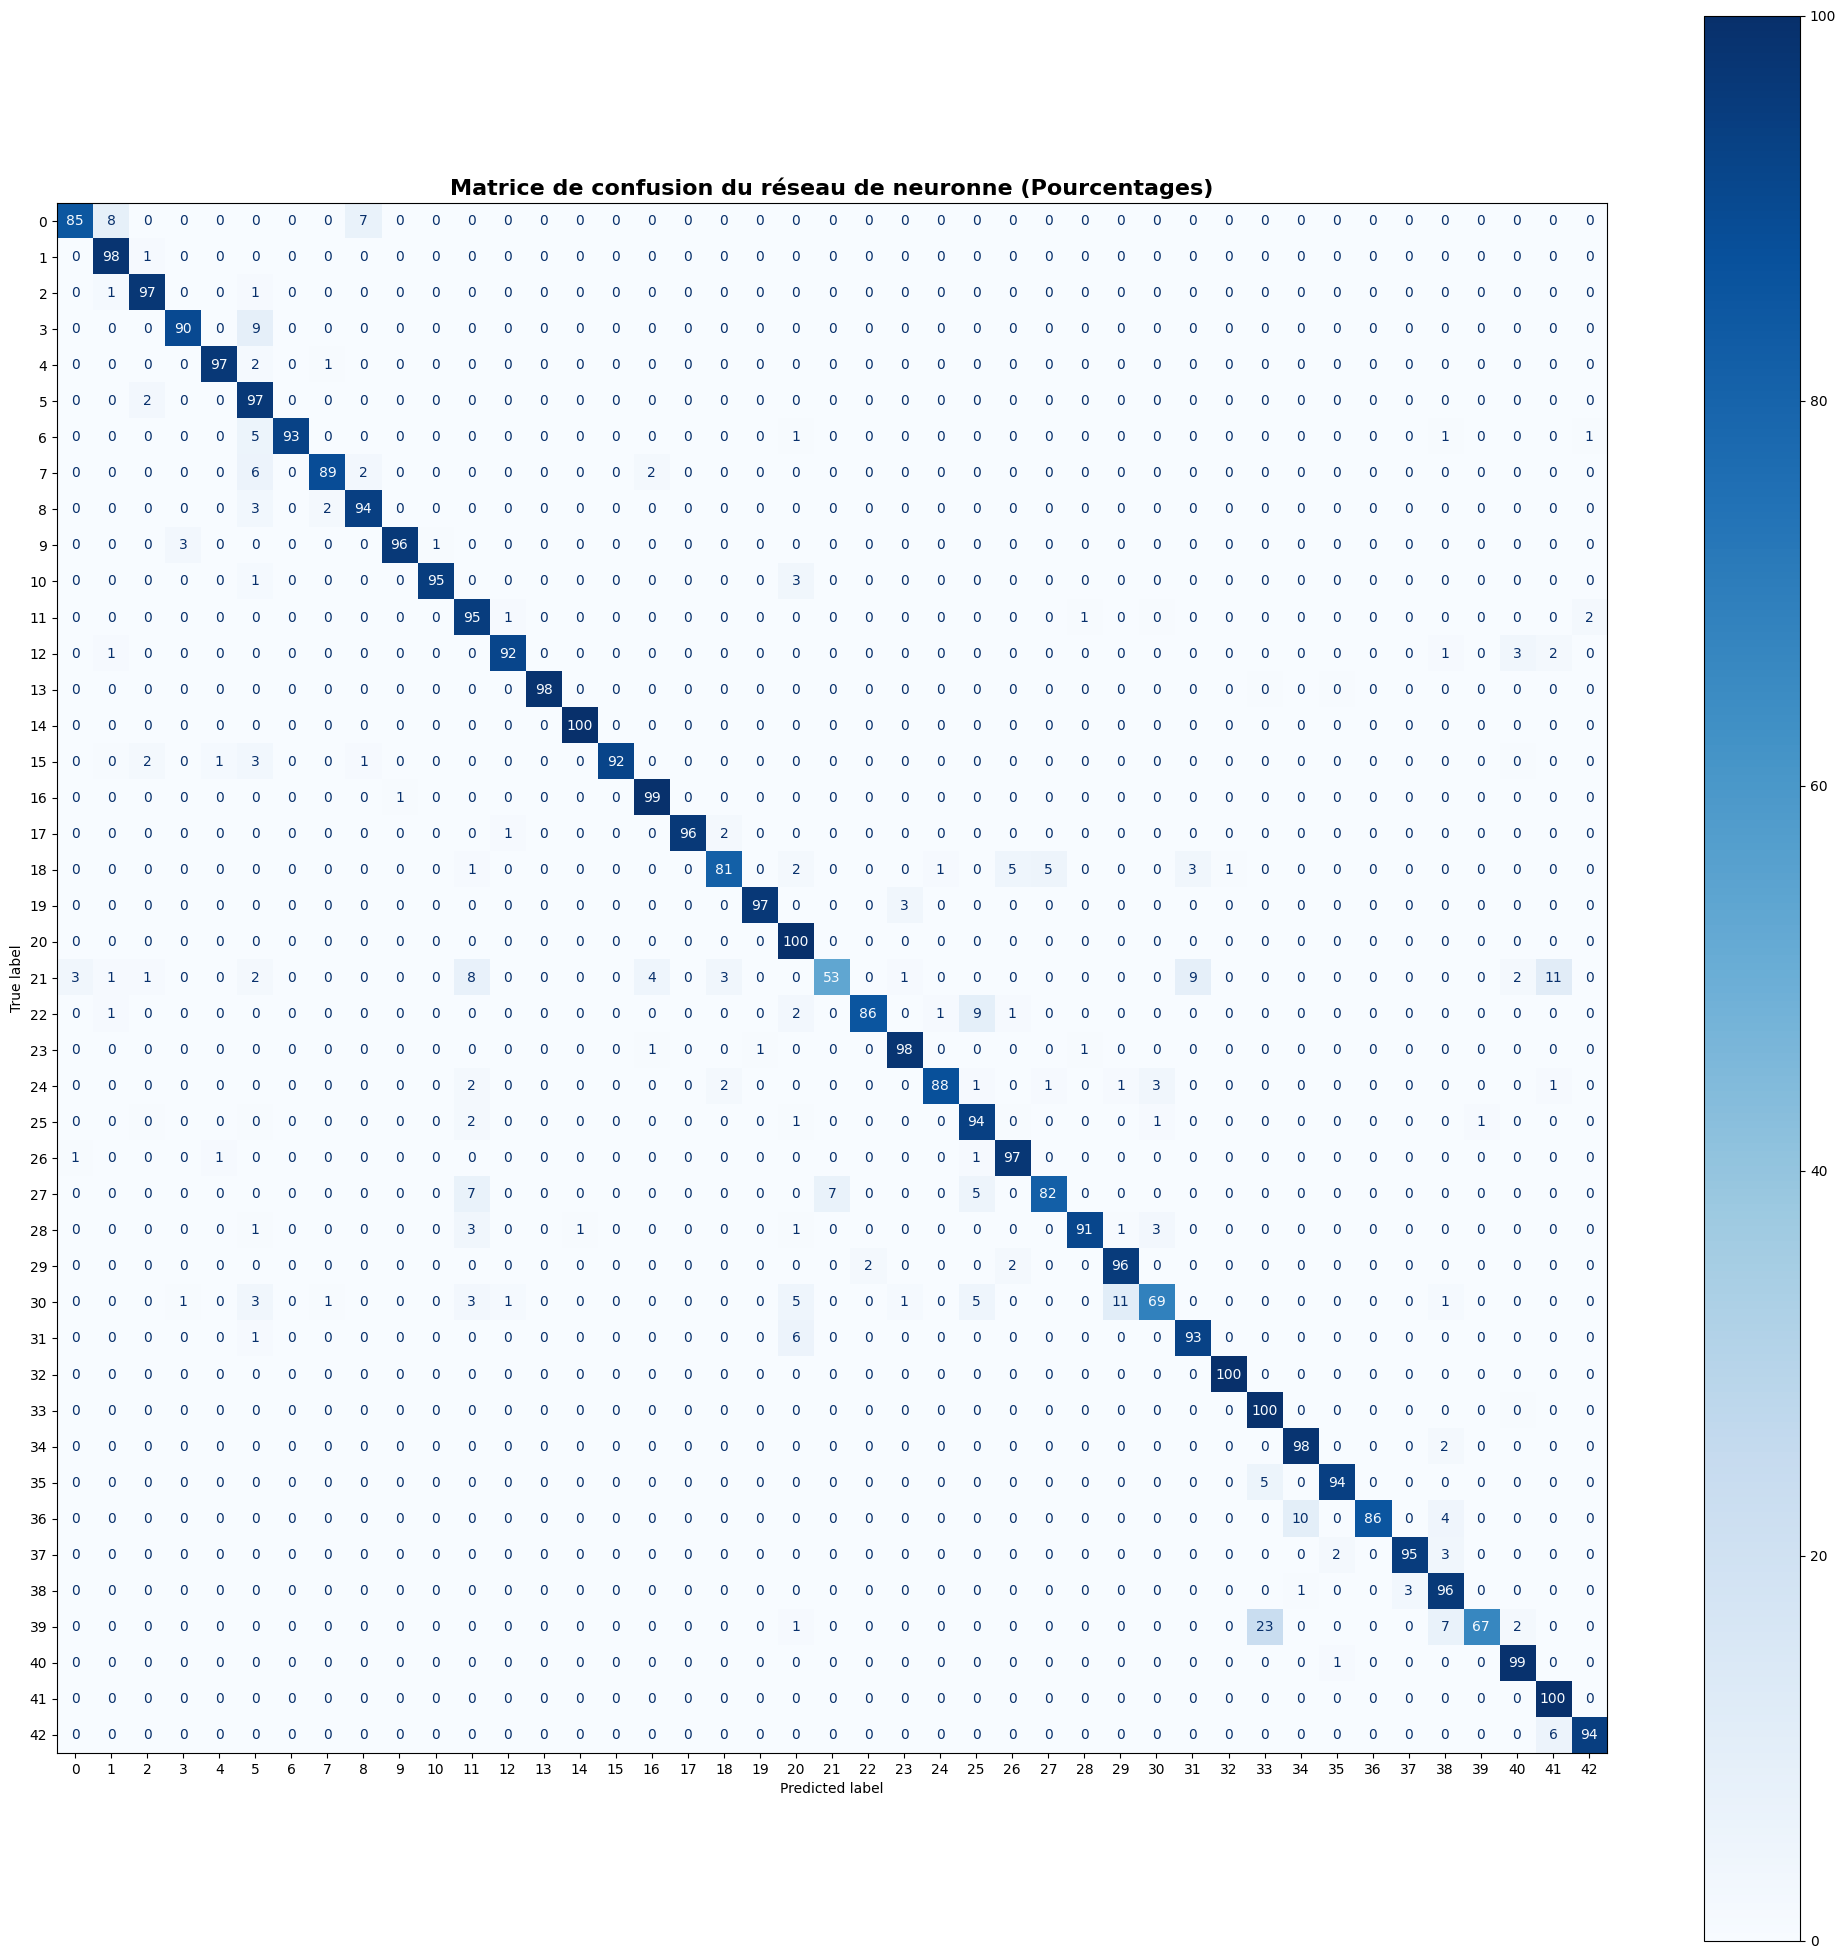

In [17]:
# Génération des prédictions
y_pred = np.argmax(cnn_model.predict(X_test), axis=1)

# Calcul de la matrice de confusion normalisée par ligne
cm = confusion_matrix(y_true, y_pred, normalize='true') * 100

# Création d'une figure assez grande pour 43 classes
fig, ax = plt.subplots(figsize=(25, 25))

# Affichage avec format pourcentage
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, values_format='.0f', ax=ax)

plt.title("Matrice de confusion du réseau de neuronne (Pourcentages)", fontsize=16, fontweight='bold')
plt.show()

In [18]:
test_loss, test_acc = cnn_model.evaluate(X_test, y_test)

print(f"Loss: {test_loss:.2f}")
print(f"Accuracy: {test_acc:.2f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9382 - loss: 0.4949
Loss: 0.49
Accuracy: 0.94


In [19]:
# On génère une liste des noms de classes pour que le tableau soit lisible
noms_classes = [CLASSES[i] for i in range(NUM_CLASSES)]

# Génération et affichage du rapport
rapport = classification_report(y_true, y_pred, target_names=noms_classes)
print(rapport)

                                        precision    recall  f1-score   support

                    Limitation 20 km/h       0.88      0.85      0.86        60
                    Limitation 30 km/h       0.96      0.98      0.97       720
                    Limitation 50 km/h       0.96      0.97      0.97       750
                    Limitation 60 km/h       0.96      0.90      0.93       450
                    Limitation 70 km/h       0.99      0.97      0.98       660
                    Limitation 80 km/h       0.82      0.97      0.89       630
             Fin de limitation 80 km/h       0.99      0.93      0.96       150
                   Limitation 100 km/h       0.95      0.89      0.92       450
                   Limitation 120 km/h       0.95      0.94      0.94       450
              Interdiction de dépasser       1.00      0.96      0.98       480
    Interdiction de dépasser (camions)       0.99      0.95      0.97       660
            Intersection avec priorité 

On observe sur la matrice de confusion que la grande majorité des panneaux sont détectés à plus de 80% excepté les panneaux "attention risque de neige", "attention passage piéton" et "attention succession de virage". <br>
La classe qui 27, soit le panneau "attention passage piéton" a un taux de bonne prédiction d'environ 50%, ce qui en fait la classe la moins bien apprise.<br>
De plus le modèle a attribué à des images de la classe 27, les classes 20, 25 et 28. Les panneaux correspondant à ces classes sont de forme triangulaire et présente un symbole s'apparentant à un bonhomme. On peut donc supposer qu'il y a un lien entre ces caractéristiques du panneau et l'hallucination du modèle.<br><br>
On observe également que la trace de la matrice de confusion du réseau de neuronnes est nettement suppérieure à celle du modèle de référence démontrant bien les meilleurs performance de notre modèle.

##**Exemple de prédiction**

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


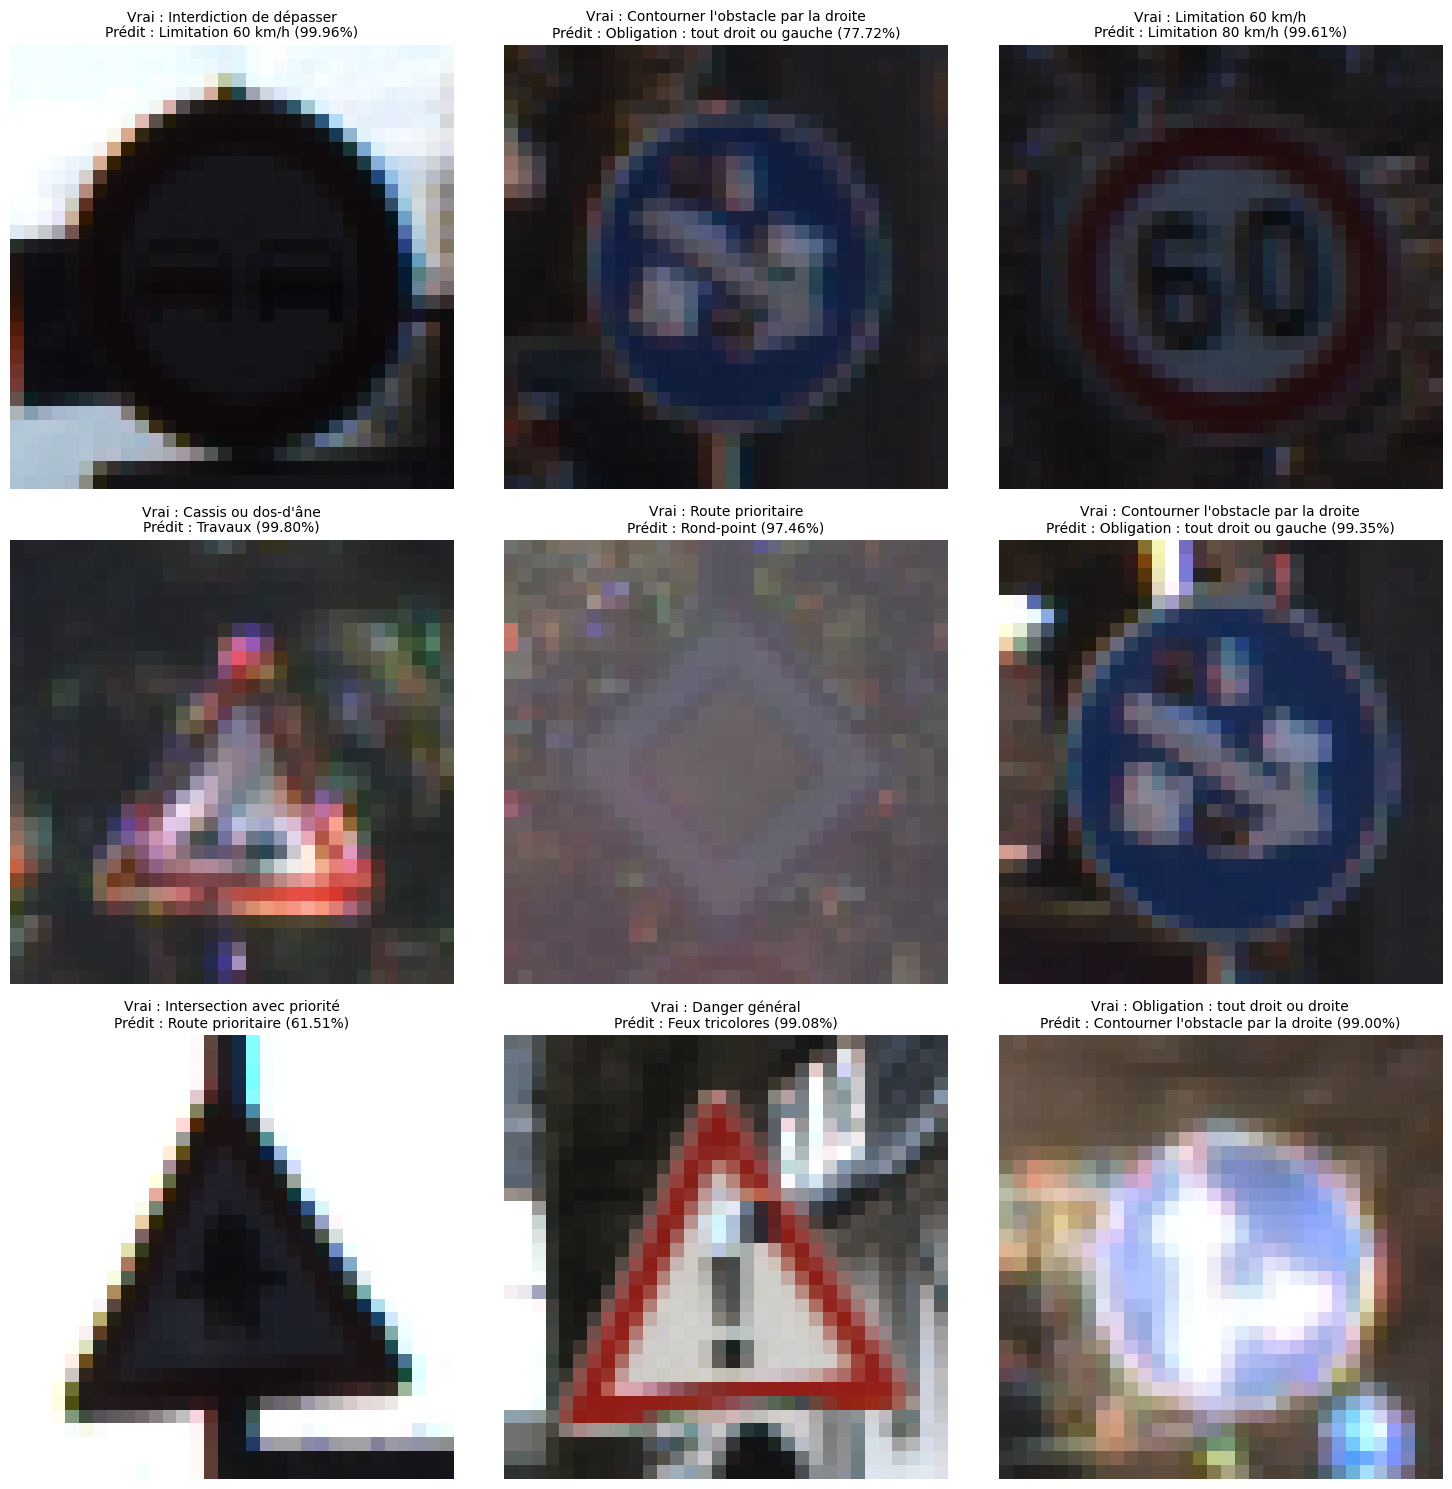

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Obtenir les probabilités et les prédictions du modèle CNN
y_pred_probs = cnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Identifier les indices des prédictions incorrectes
misclassified_indices = np.where(y_pred_classes != y_true_classes)[0]

# Choisir un échantillon aléatoire de prédictions incorrectes à afficher
np.random.seed(42)
num_examples = min(9, len(misclassified_indices))
selected_indices = np.random.choice(misclassified_indices, size=num_examples, replace=False)

# Tracer les exemples
plt.figure(figsize=(15, 15))
for i, idx in enumerate(selected_indices):
    plt.subplot(3, 3, i + 1)

    # Afficher l'image
    plt.imshow(X_test[idx])

    # Récupérer les informations
    true_label = CLASSES[y_true_classes[idx]]
    pred_label = CLASSES[y_pred_classes[idx]]
    prob = y_pred_probs[idx][y_pred_classes[idx]] * 100

    # Titre avec les détails demandés
    plt.title(f"Vrai : {true_label}\nPrédit : {pred_label} ({prob:.2f}%)", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Grâce à l'affichage d'exemple d'erreur de prédictions, on observe que le modèle n'arrive pas à analyser les images extrêmes, que ce soit des images trop éclairées ou trop peu.<br>
Cependant, l'angle et la netteté du panneaux ne semble pas avoir un grand impact sur la réussite du modèle.

# **Partie 6 — Expérimentation et amélioration**

In [21]:
from tensorflow.keras.layers import RandomRotation, RandomZoom
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_cnn(dropout=False, augmentation=False, name="cnn"):
    model = Sequential(name=name)
    model.add(Input(shape=(IMG_SIZE, IMG_SIZE, CHANNEL)))
    if augmentation:
        model.add(RandomRotation(0.04))     # ±14°
        model.add(RandomZoom(0.1))
    for nb_neurons in (32, 64, 128):
        model.add(Conv2D(nb_neurons, (3, 3), padding="same", activation="relu"))
        model.add(MaxPooling2D((2, 2)))
        if dropout:
          model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    if dropout:
        model.add(Dropout(0.5))
    model.add(Dense(NUM_CLASSES, activation="softmax"))
    return model

def run_exp(model, max_epochs=20, early_stopping=False):
    model.compile(loss="categorical_crossentropy",
                  optimizer="adam",
                  metrics=["accuracy"])

    callbacks = []
    if early_stopping:
        callbacks.append(EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ))

    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=max_epochs,
                        callbacks=callbacks
                        )
    return history



## **Exp 1 : Early stopping**

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6347 - loss: 1.2719 - val_accuracy: 0.9226 - val_loss: 0.2670
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9587 - loss: 0.1454 - val_accuracy: 0.9416 - val_loss: 0.1894
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9830 - loss: 0.0602 - val_accuracy: 0.9751 - val_loss: 0.0952
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9890 - loss: 0.0375 - val_accuracy: 0.9805 - val_loss: 0.0696
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9907 - loss: 0.0328 - val_accuracy: 0.9596 - val_loss: 0.1409
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9927 - loss: 0.0241 - val_accuracy: 0.9819 - val_loss: 0.0710
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9937 - loss: 0.0214 - val_accuracy: 0.9875 - val_loss: 0.0530
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9942 - loss: 0.0204 - val_accuracy: 0

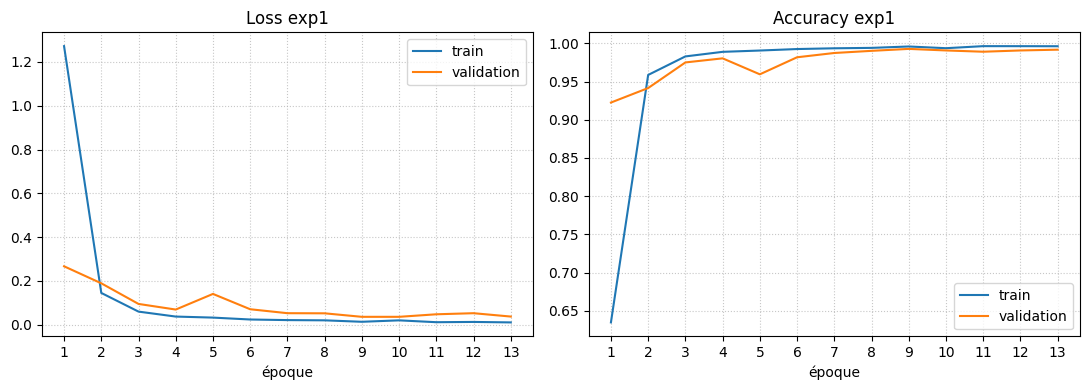

In [23]:
#Construction du modèle CNN pour l'Exp 1
exp1_model = build_cnn(dropout=False, augmentation=False, name="exp1")

#Exécution de l'entraînement avec Early Stopping activé
exp1_history = run_exp(exp1_model, max_epochs=20, early_stopping=True)

h_exp1 = exp1_history.history

#Visualisation des courbes d'apprentissage de l'expérience
plot_history(h_exp1, "exp1")

In [24]:
import pickle

# Sauvegarde du modèle de l'expérience 1
exp1_model.save("exp1_model.keras")

# Sauvegarde l'historique d'entrainement de l'expérience 1
with open("h_exp1.pkl", "wb") as f:
    pickle.dump(h_exp1, f)


In [ ]:
!wget https://raw.githubusercontent.com/Minetriforce/DL_project_traffic_signs/main/saves/history/h_exp1.pkl
!wget https://raw.githubusercontent.com/Minetriforce/DL_project_traffic_signs/main/saves/models/exp1_model.keras

In [ ]:
import pickle
from tensorflow.keras.models import load_model

# Récupération de l'historique d'entrainement et du modèle de l'exp 1
with open('h_exp1.pkl', 'rb') as f:
    h_exp1 = pickle.load(f)

exp1_model = load_model('exp1_model.keras')

## **Exp 2 : Dropout**

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.3322 - loss: 2.2991 - val_accuracy: 0.6407 - val_loss: 1.1946
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6753 - loss: 0.9894 - val_accuracy: 0.9092 - val_loss: 0.3536
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8252 - loss: 0.5317 - val_accuracy: 0.9545 - val_loss: 0.1808
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8874 - loss: 0.3482 - val_accuracy: 0.9739 - val_loss: 0.1050
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9140 - loss: 0.2674 - val_accuracy: 0.9850 - val_loss: 0.0653
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9336 - loss: 0.2068 - val_accuracy: 0.9889 - val_loss: 0.0460
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9456 - loss: 0.1687 - val_accuracy: 0.9906 - val_loss: 0.0324
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9544 - loss: 0.1462 - val_accuracy: 

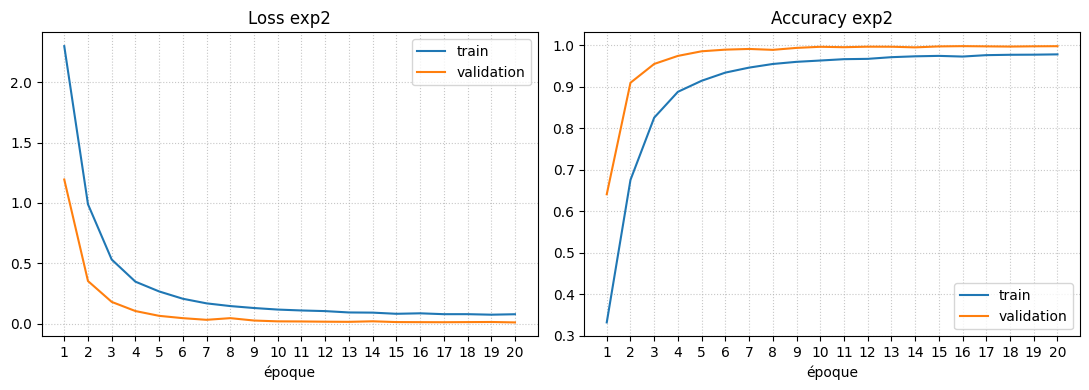

In [25]:
exp2_model = build_cnn(dropout=True, augmentation=False, name="exp2")

exp2_history = run_exp(exp2_model, max_epochs=20)

h_exp2 = exp2_history.history

plot_history(h_exp2, "exp2")


In [26]:
import pickle

# Sauvegarde du modèle de l'expérience 2
exp2_model.save("exp2_model.keras")

# Sauvegarde l'historique d'entrainement de l'expérience 2
with open("h_exp2.pkl", "wb") as f:
    pickle.dump(h_exp2, f)


In [ ]:
!wget https://raw.githubusercontent.com/Minetriforce/DL_project_traffic_signs/main/saves/history/h_exp2.pkl
!wget https://raw.githubusercontent.com/Minetriforce/DL_project_traffic_signs/main/saves/models/exp2_model.keras

In [ ]:
import pickle
from tensorflow.keras.models import load_model

# Récupération de l'historique d'entrainement et du modèle de l'exp 2
with open('h_exp2.pkl', 'rb') as f:
    h_exp2 = pickle.load(f)

exp2_model = load_model('exp2_model.keras')

## **Exp 3 : Data Augmentation**

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5477 - loss: 1.5650 - val_accuracy: 0.8462 - val_loss: 0.4874
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9025 - loss: 0.3178 - val_accuracy: 0.9617 - val_loss: 0.1456
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9564 - loss: 0.1445 - val_accuracy: 0.9774 - val_loss: 0.0870
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9721 - loss: 0.0923 - val_accuracy: 0.9700 - val_loss: 0.0999
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9776 - loss: 0.0719 - val_accuracy: 0.9843 - val_loss: 0.0570
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9852 - loss: 0.0498 - val_accuracy: 0.9821 - val_loss: 0.0684
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9853 - loss: 0.0498 - val_accuracy: 0.9902 - val_loss: 0.0403
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9879 - loss: 0.0414 - val_accura

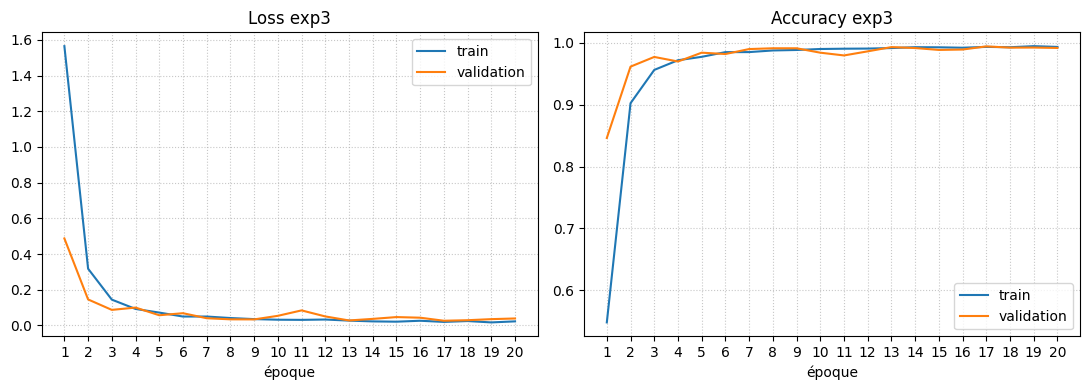

In [27]:
exp3_model = build_cnn(dropout=False, augmentation=True, name="exp3")

exp3_history = run_exp(exp3_model, max_epochs=20)

h_exp3 = exp3_history.history

plot_history(h_exp3, "exp3")


In [28]:
import pickle

# Sauvegarde du modèle de l'expérience 3
exp3_model.save("exp3_model.keras")

# Sauvegarde l'historique d'entrainement de l'expérience 3
with open("h_exp3.pkl", "wb") as f:
    pickle.dump(h_exp3, f)


In [ ]:
!wget https://raw.githubusercontent.com/Minetriforce/DL_project_traffic_signs/main/saves/history/h_exp3.pkl
!wget https://raw.githubusercontent.com/Minetriforce/DL_project_traffic_signs/main/saves/models/exp3_model.keras

In [ ]:
import pickle
from tensorflow.keras.models import load_model

# Récupération de l'historique d'entrainement et du modèle de l'exp 3
with open('h_exp3.pkl', 'rb') as f:
    h_exp3 = pickle.load(f)

exp3_model = load_model('exp3_model.keras')

## **Exp 4 : Tout ensemble**

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.3214 - loss: 2.3311 - val_accuracy: 0.6202 - val_loss: 1.2219
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6025 - loss: 1.1955 - val_accuracy: 0.8660 - val_loss: 0.5342
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7571 - loss: 0.7372 - val_accuracy: 0.9234 - val_loss: 0.2599
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8290 - loss: 0.5229 - val_accuracy: 0.9647 - val_loss: 0.1412
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8640 - loss: 0.4058 - val_accuracy: 0.9750 - val_loss: 0.0926
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8900 - loss: 0.3360 - val_accuracy: 0.9839 - val_loss: 0.0678
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9106 - loss: 0.2745 - val_accuracy: 0.9804 - val_loss: 0.0642
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9213 - loss: 0.2438 - val_

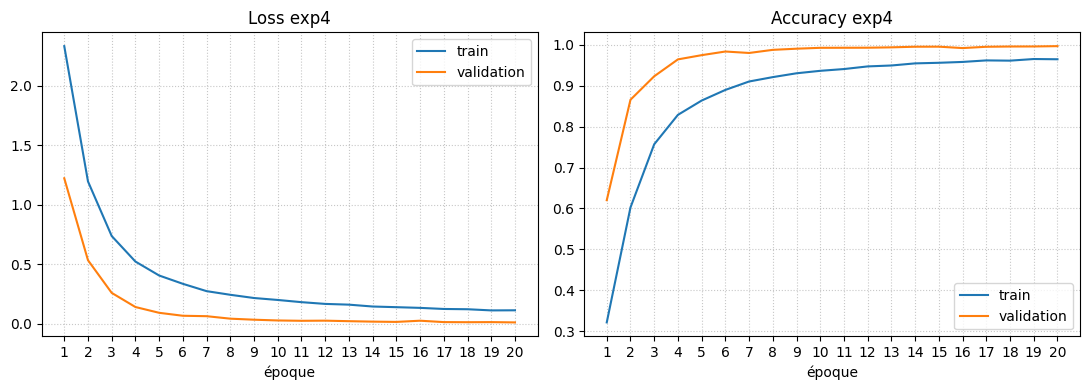

In [29]:
#Construction du modèle CNN pour l'Exp 4
exp4_model = build_cnn(dropout=True, augmentation=True, name="exp4")

#Exécution de l'entraînement avec Early Stopping, Dropout et Data Augmentation
exp4_history = run_exp(exp4_model, max_epochs=40, early_stopping=True)

h_exp4 = exp4_history.history

#Visualisation des courbes d'apprentissage de l'expérience
plot_history(h_exp4, "exp4")

In [30]:
import pickle

# Sauvegarde du modèle de l'expérience 4
exp4_model.save("exp4_model.keras")

# Sauvegarde l'historique d'entrainement de l'expérience 4
with open("h_exp4.pkl", "wb") as f:
    pickle.dump(h_exp4, f)


In [ ]:
!wget https://raw.githubusercontent.com/Minetriforce/DL_project_traffic_signs/main/saves/history/h_exp4.pkl
!wget https://raw.githubusercontent.com/Minetriforce/DL_project_traffic_signs/main/saves/models/exp4_model.keras

In [ ]:
import pickle
from tensorflow.keras.models import load_model

# Récupération de l'historique d'entrainement et du modèle de l'exp 4
with open('h_exp4.pkl', 'rb') as f:
    h_exp4 = pickle.load(f)

exp4_model = load_model('exp4_model.keras')

##**Résultats**

In [41]:
import pandas as pd

results = {}

def fill_results(h_all_exps, names_exp):
  b0 = int(np.argmin(h_cnn["val_loss"]))
  results["CNN normal"] = {
      "epochs": len(h_cnn["loss"]),
      "best_epoch": b0 + 1,
      "train_acc": h_cnn["accuracy"][b0],
      "val_acc": h_cnn["val_accuracy"][b0],
      "val_loss": h_cnn["val_loss"][b0]}

  for h, name in zip(h_all_exps, names_exp):
      b = int(np.argmin(h["val_loss"]))
      results[name] = { "epochs": len(h["loss"]),
                       "best_epoch": b + 1,
                       "train_acc": h["accuracy"][b],
                       "val_acc": h["val_accuracy"][b],
                       "val_loss": h["val_loss"][b]}

names_exp = ["Early Stopping",
             "Dropout",
             "Data Augmentation",
             "Tout ensemble"]

h_all_exps = [h_exp1, h_exp2, h_exp3, h_exp4]

fill_results(h_all_exps, names_exp)

# Mise en page
data_results = [
    {
        'Expérience': nom,
        'Nombre Époques': r['epochs'],
        'Meilleur époque': r['best_epoch'],
        'Acc. train': round(r['train_acc'], 4),
        'Acc. val': round(r['val_acc'], 4),
        'Loss val': round(r['val_loss'], 4)
    }
    for nom, r in results.items()
]

df_results = pd.DataFrame(data_results)

display(df_results)

,Expérience,Nombre Époques,Meilleur époque,Acc. train,Acc. val,Loss val
0,CNN normal,20,13,0.9971,0.9949,0.0255
1,Early Stopping,13,10,0.9938,0.9908,0.0364
2,Dropout,20,20,0.9775,0.9972,0.0109
3,Data Augmentation,20,17,0.9937,0.9945,0.0262
4,Tout ensemble,20,20,0.9650,0.9971,0.0120
